In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv('../datasets/latinbiota_merge_metaphlan_data.csv', sep = '\t', skiprows=1, index_col = 0)
metadata = pd.read_excel('../data/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')
dict_in = {'Child':'Child', 'Adult':'Adult', 'Infant':'Child', 'Elderly':'Elderly', 'Teenager':'Adult'}
metadata['age'] = [dict_in[x] for x in list(metadata['Age group'].fillna('Adult'))]

data_sp = data[data.index.astype(str).str.contains("g__")]
data_sp = data_sp[~data_sp.index.astype(str).str.contains("t__")]
data_sp = data_sp[~data_sp.index.astype(str).str.contains("s__")]
data_sp = data_sp[~data_sp.index.astype(str).str.contains("unclass")]

new = []

for item in data_sp.index:
    new.append(item.split('|g__')[1].replace('|t__', ' ').replace('_', ' '))

data_sp.index = new
data_sp = data_sp.T
# data_sp.describe()

rare = ['37082_3#16',
'37082_2#4',
'37035_2#22',
'37035_7#18',
'36703_3#20',
'36703_3#4']

# order = list(pd.read_csv('../datasets/metadata.csv')['SampleID'])
# data_sp2 = data_sp.loc[[x for x in order if x in data_sp.index]]
data_sp2 = data_sp.drop(rare)

In [137]:
metadata.head()

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent,age
0,37082_3_9,37082_3#9,GI1_LA9438076,50,47,18623506,37082_3_9,Latinbiota,Healthy,NaN,18.1,NaN,7.0,Child,Male,Rural,Mexico,North America,Child
1,37082_3_8,37082_3#8,GI1_LA9438075,49,76,27292796,37082_3_8,Latinbiota,Healthy,NaN,18.7,NaN,9.0,Child,Male,Rural,Mexico,North America,Child
2,37082_3_7,37082_3#7,GI1_LA9438074,47,73,23589062,37082_3_7,Latinbiota,Healthy,NaN,23.5,NaN,23.0,Adult,Female,Rural,Mexico,North America,Adult
3,37082_3_6,37082_3#6,GI1_LA9438073,76,161,17556434,37082_3_6,Latinbiota,Healthy,NaN,14.9,NaN,6.0,Child,Male,Rural,Mexico,North America,Child
4,37082_3_5,37082_3#5,GI1_LA9438072,73,159,23119984,37082_3_5,Latinbiota,Healthy,NaN,26.5,NaN,30.0,Adult,Female,Rural,Mexico,North America,Adult


In [12]:
rural = list(metadata[metadata['Lifestyle'] == 'Rural']['Lane'])
urban = list(metadata[metadata['Lifestyle'] == 'Urban']['Lane'])

label = []
for x in data_sp2.index:
    if x in rural:
        label.append(1)
    elif x in urban:
        label.append(0)
    else:
        label.append('None')

In [140]:
group = []
sex = []
for item in data_sp2.index:
    group.append(metadata[metadata['Lane'] == item]['age'].iloc[0])
    sex.append(metadata[metadata['Lane'] == item]['Gender'].iloc[0])

In [20]:
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier

In [76]:
model = xgb.XGBClassifier()

model2 = DecisionTreeClassifier()

model.fit(data_sp2, label)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [77]:
model.predict(data_sp2)

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

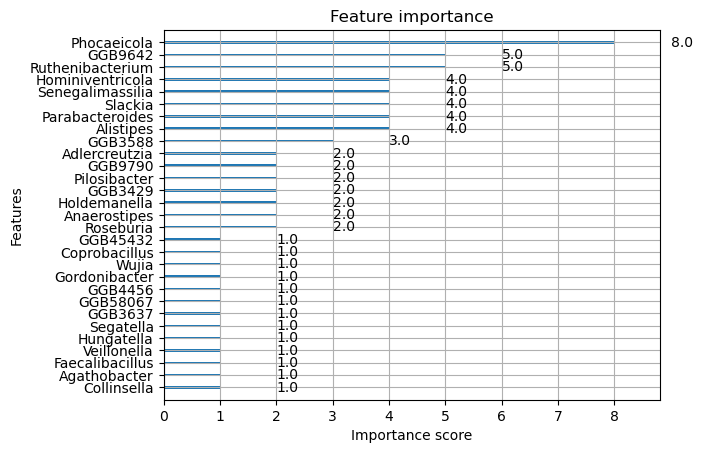

In [78]:
xgb.plot_importance(model)

In [81]:
explainer = shap.Explainer(model.predict, data_sp2)

In [82]:
shap_values = explainer.shap_values(data_sp2)


ermutationExplainer explainer: 200it [16:27,  4.96s/it]                                                               

C:\Users\rafap\AppData\Local\Temp\ipykernel_13856\4261690061.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, data_sp2)


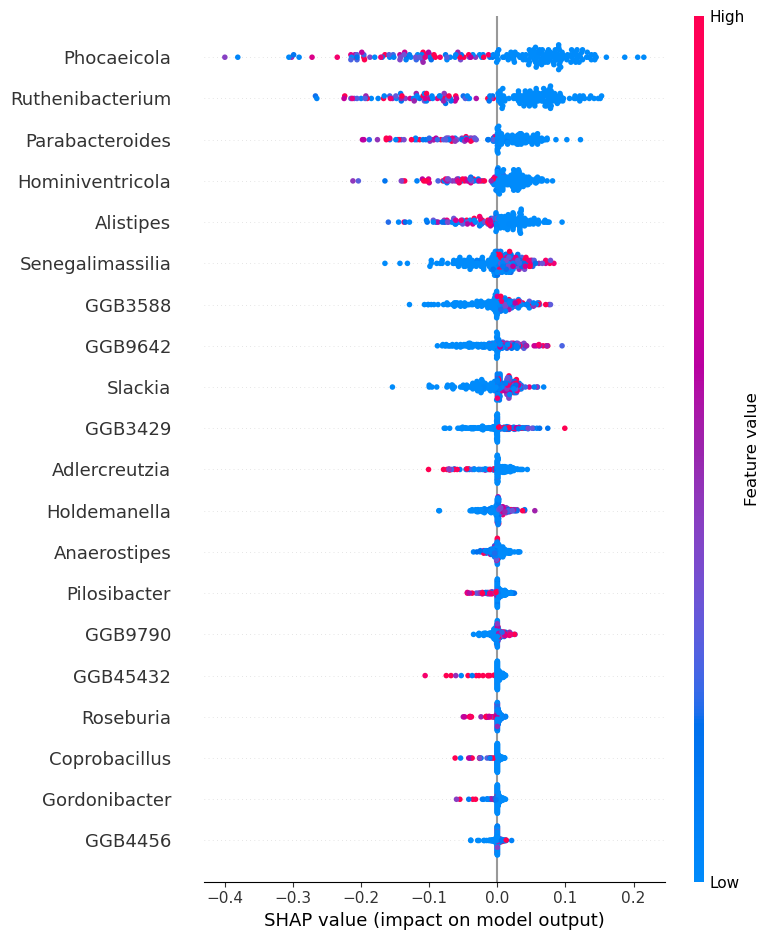

In [83]:
shap.summary_plot(shap_values, data_sp2)

In [90]:
# shap_values_class1 = shap_values[:, :, 1]
shap_df = pd.DataFrame(shap_values_class1, columns=data_sp2.columns, index = data_sp2.index)

shap_df.head()

,Bacteroides,Bifidobacterium,Phocaeicola,Fusicatenibacter,Roseburia,Hominilimicola,Blautia,Faecalibacterium,GGB4605,Ruminococcus,...,Sphingomonas,GGB109105,GGB142492,GGB9763,GGB101460,GGB100295,GGB79087,GGB18111,GGB13711,Pauljensenia
36703_3#10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36703_3#12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36703_3#13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36703_3#14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36703_3#15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [93]:
shap_df.describe()

,Bacteroides,Bifidobacterium,Phocaeicola,Fusicatenibacter,Roseburia,Hominilimicola,Blautia,Faecalibacterium,GGB4605,Ruminococcus,...,Sphingomonas,GGB109105,GGB142492,GGB9763,GGB101460,GGB100295,GGB79087,GGB18111,GGB13711,Pauljensenia
count,199.0,199.0,199.0,199.0,199.0,199.0,199.0,199.0,199.0,199.0,...,199.0,199.0,199.0,199.0,199.0,199.0,199.0,199.0,199.0,199.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


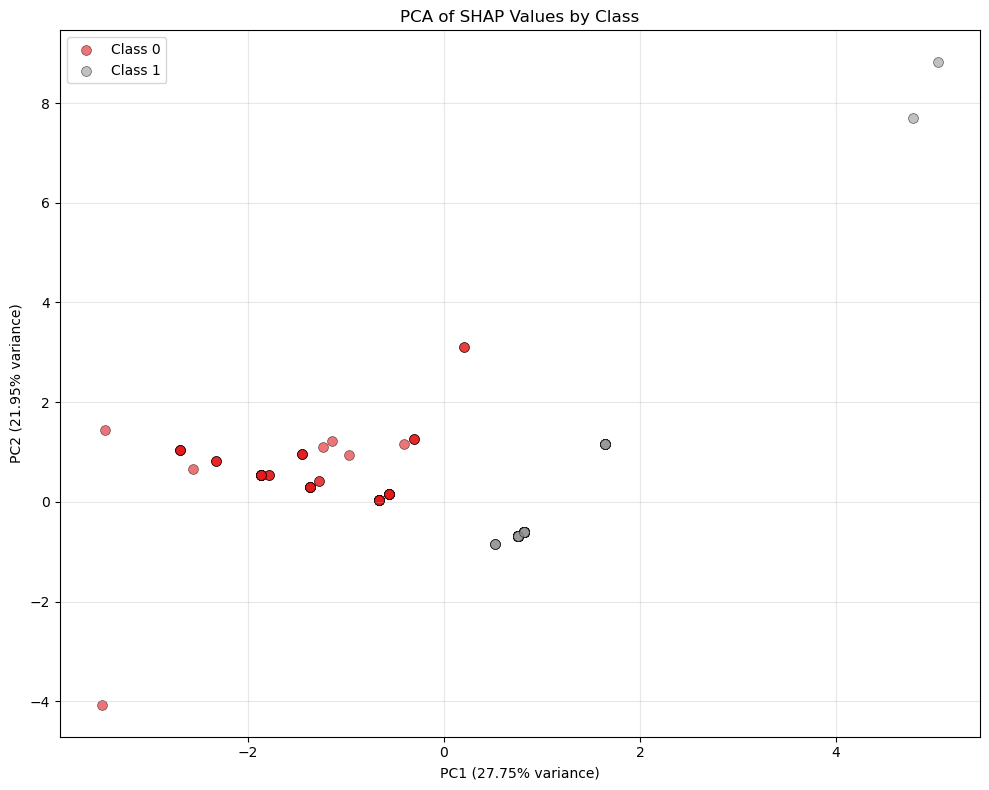

Total variance explained: 49.70%


In [102]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Standardize SHAP values before PCA
scaler = StandardScaler()
shap_scaled = scaler.fit_transform(shap_df)

# Apply PCA to scaled SHAP values
pca = PCA(n_components=2)
shap_pca = pca.fit_transform(shap_scaled)

# Create DataFrame with results
pca_df = pd.DataFrame({
    'PC1': shap_pca[:, 0],
    'PC2': shap_pca[:, 1],
    'label': label
})

unique_labels = np.unique(label)
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))

plt.figure(figsize=(10, 8))
for i, lbl in enumerate(unique_labels):
    mask = pca_df['label'] == lbl
    plt.scatter(pca_df.loc[mask, 'PC1'], 
               pca_df.loc[mask, 'PC2'],
               c=[colors[i]], 
               label=f'Class {lbl}',
               alpha=0.6,
               edgecolors='black',
               linewidth=0.5,
               s=50)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA of SHAP Values by Class')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

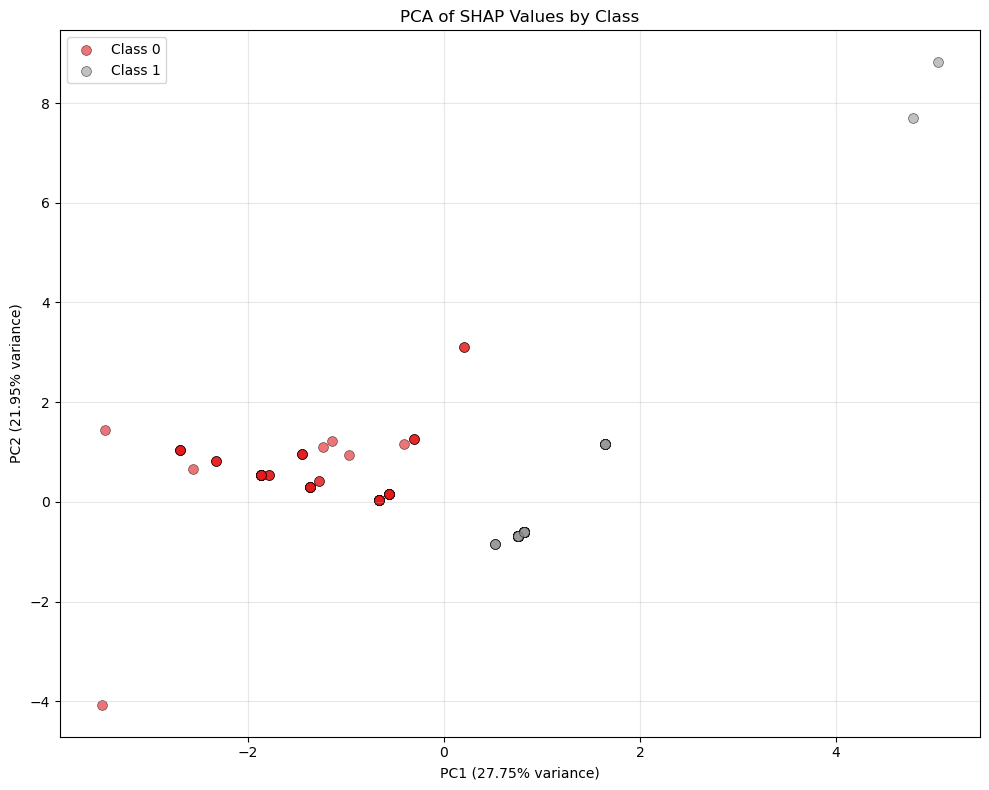

Total variance explained: 49.70%

First few rows with sample IDs:
    sample_id       PC1       PC2  label
0  36703_3#10 -0.565390  0.162895      0
1  36703_3#12  0.757246 -0.688289      1
2  36703_3#13  0.757246 -0.688289      1
3  36703_3#14  0.757246 -0.688289      1
4  36703_3#15  0.757246 -0.688289      1


In [104]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Standardize SHAP values before PCA
scaler = StandardScaler()
shap_scaled = scaler.fit_transform(shap_df)

# Apply PCA to scaled SHAP values
pca = PCA(n_components=2)
shap_pca = pca.fit_transform(shap_scaled)

# Create DataFrame with results INCLUDING the index/ID
pca_df = pd.DataFrame({
    'sample_id': shap_df.index,  # Add the index from shap_df
    'PC1': shap_pca[:, 0],
    'PC2': shap_pca[:, 1],
    'label': label
})

# Reset index if you want sample_id as a column (not as index)
# pca_df = pca_df.reset_index(drop=True)  # Optional

unique_labels = np.unique(label)
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))

plt.figure(figsize=(10, 8))
for i, lbl in enumerate(unique_labels):
    mask = pca_df['label'] == lbl
    plt.scatter(pca_df.loc[mask, 'PC1'], 
               pca_df.loc[mask, 'PC2'],
               c=[colors[i]], 
               label=f'Class {lbl}',
               alpha=0.6,
               edgecolors='black',
               linewidth=0.5,
               s=50)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA of SHAP Values by Class')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print("\nFirst few rows with sample IDs:")
print(pca_df.head())

In [116]:
c2 = list(pca_df[(pca_df['PC2'] > 0) & (pca_df['label'] == 1) & (pca_df['PC2'] < 4)]['sample_id'])

In [117]:
c2

['36703_3#26',
 '37035_1#12',
 '37035_7#16',
 '37082_2#16',
 '37082_2#28',
 '37082_3#21',
 '37082_3#22',
 '37082_3#27',
 '37082_3#30',
 '37082_3#8']

In [118]:
metadata[metadata['Lane'].isin(c2)]

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent,age
1,37082_3_8,37082_3#8,GI1_LA9438075,49,76,27292796,37082_3_8,Latinbiota,Healthy,NaN,18.7,NaN,9.0,Child,Male,Rural,Mexico,North America,Child
8,37082_3_30,37082_3#30,GI1_LA9438105,101,B6,26078302,37082_3_30,Latinbiota,Healthy,NaN,14.9,NaN,9.0,Child,Male,Rural,Mexico,North America,Child
12,37082_3_27,37082_3#27,GI1_LA9438101,B6,B2,18395666,37082_3_27,Latinbiota,Healthy,NaN,27.1,NaN,30.0,Adult,Female,Rural,Mexico,North America,Adult
17,37082_3_22,37082_3#22,GI1_LA9438092,B32,B24,21996300,37082_3_22,Latinbiota,Healthy,NaN,NaN,NaN,4.0,Child,Male,Rural,Mexico,North America,Child
18,37082_3_21,37082_3#21,GI1_LA9438091,B31,B23,21997000,37082_3_21,Latinbiota,Healthy,NaN,25.8,NaN,86.0,Elderly,Female,Rural,Mexico,North America,Elderly
43,37082_2_28,37082_2#28,GI1_LA9438058,10,28,21295554,37082_2_28,Latinbiota,Healthy,NaN,18.3,NaN,7.0,Child,Female,Rural,Mexico,North America,Child
56,37082_2_16,37082_2#16,GI1_LA9438044,12,C69,22974510,37082_2_16,Latinbiota,Healthy,NaN,25.1,NaN,29.0,Adult,Female,Rural,Mexico,North America,Adult
105,37035_7_16,37035_7#16,GI1_LA9825335,23,23,22648068,37035_7_16,Latinbiota,Healthy,NaN,16.6,NaN,8.0,Child,Female,Rural,Mexico,North America,Child
172,37035_1_12,37035_1#12,GI1_LA9438123,94,92,27844308,37035_1_12,Latinbiota,Healthy,NaN,22.9,NaN,35.0,Adult,Female,Rural,Mexico,North America,Adult
189,36703_3_26,36703_3#26,GI1_LA9438111,121,134,23942272,36703_3_26,Latinbiota,Diseased,Obesity,30.2,NaN,29.0,Adult,Female,Rural,Mexico,North America,Adult


C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


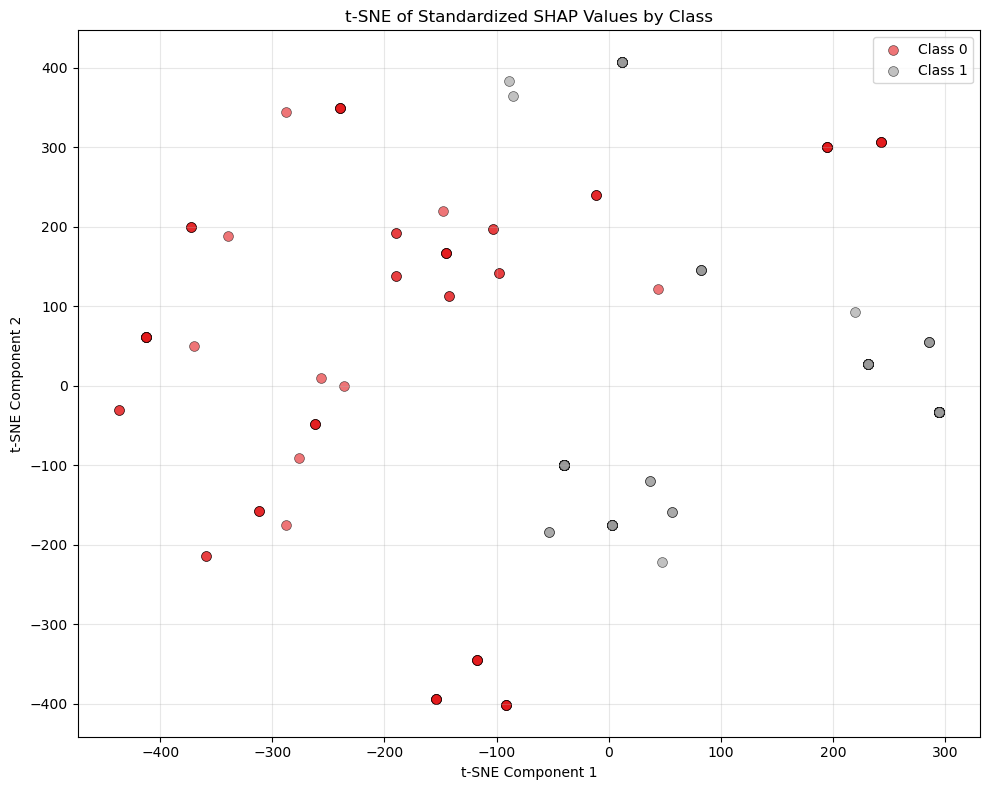

In [150]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np

# Standardize SHAP values before t-SNE
scaler = StandardScaler()
shap_scaled = scaler.fit_transform(shap_df)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5, n_iter=1000)
shap_tsne = tsne.fit_transform(shap_scaled)

# Create DataFrame with results
tsne_df = pd.DataFrame({
    'TSNE1': shap_tsne[:, 0],
    'TSNE2': shap_tsne[:, 1],
    'label': label
})

# Plot
unique_labels = np.unique(label)
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))

plt.figure(figsize=(10, 8))
for i, lbl in enumerate(unique_labels):
    mask = tsne_df['label'] == lbl
    plt.scatter(tsne_df.loc[mask, 'TSNE1'], 
               tsne_df.loc[mask, 'TSNE2'],
               c=[colors[i]], 
               label=f'Class {lbl}',
               alpha=0.6,
               edgecolors='black',
               linewidth=0.5,
               s=50)

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE of Standardized SHAP Values by Class')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [151]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Add group and sex to tsne_df
tsne_df["group"] = group
tsne_df["sex"] = tsne_df["sex"].fillna("unknown")
# Define unique values
unique_labels = np.unique(tsne_df["label"])
unique_groups = np.unique(tsne_df["group"])
unique_sex = np.unique(tsne_df["sex"])

# Colors for labels
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))

# Marker shapes for sex
# Safe mapping: only as many markers as unique sex values
markers = ["o", "s", "D", "^", "v"]
marker_dict = {sex_val: markers[i % len(markers)] for i, sex_val in enumerate(unique_sex)}

# Create subplots by group
fig, axes = plt.subplots(1, len(unique_groups), figsize=(6 * len(unique_groups), 6), sharex=True, sharey=True)

if len(unique_groups) == 1:
    axes = [axes]  # make iterable if only one subplot

for ax, grp in zip(axes, unique_groups):
    sub = tsne_df[tsne_df["group"] == grp]
    for i, lbl in enumerate(unique_labels):
        for s in unique_sex:
            mask = (sub["label"] == lbl) & (sub["sex"] == s)
            ax.scatter(
                sub.loc[mask, "TSNE1"],
                sub.loc[mask, "TSNE2"],
                c=[colors[i]],
                marker=marker_dict[s],
                label=f"Class {lbl} ({s})",
                alpha=0.7,
                edgecolors="black",
                linewidth=0.5,
                s=50
            )
    ax.set_title(f"Group: {grp}")
    ax.set_xlabel("t-SNE Component 1")
    ax.set_ylabel("t-SNE Component 2")
    ax.grid(True, alpha=0.3)

# Create a single legend outside the plot
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.05, 0.5), loc="center left", title="Class & Sex")
plt.suptitle("t-SNE of SHAP Values by Class, Age Group, and Sex", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


KeyError: 'sex'

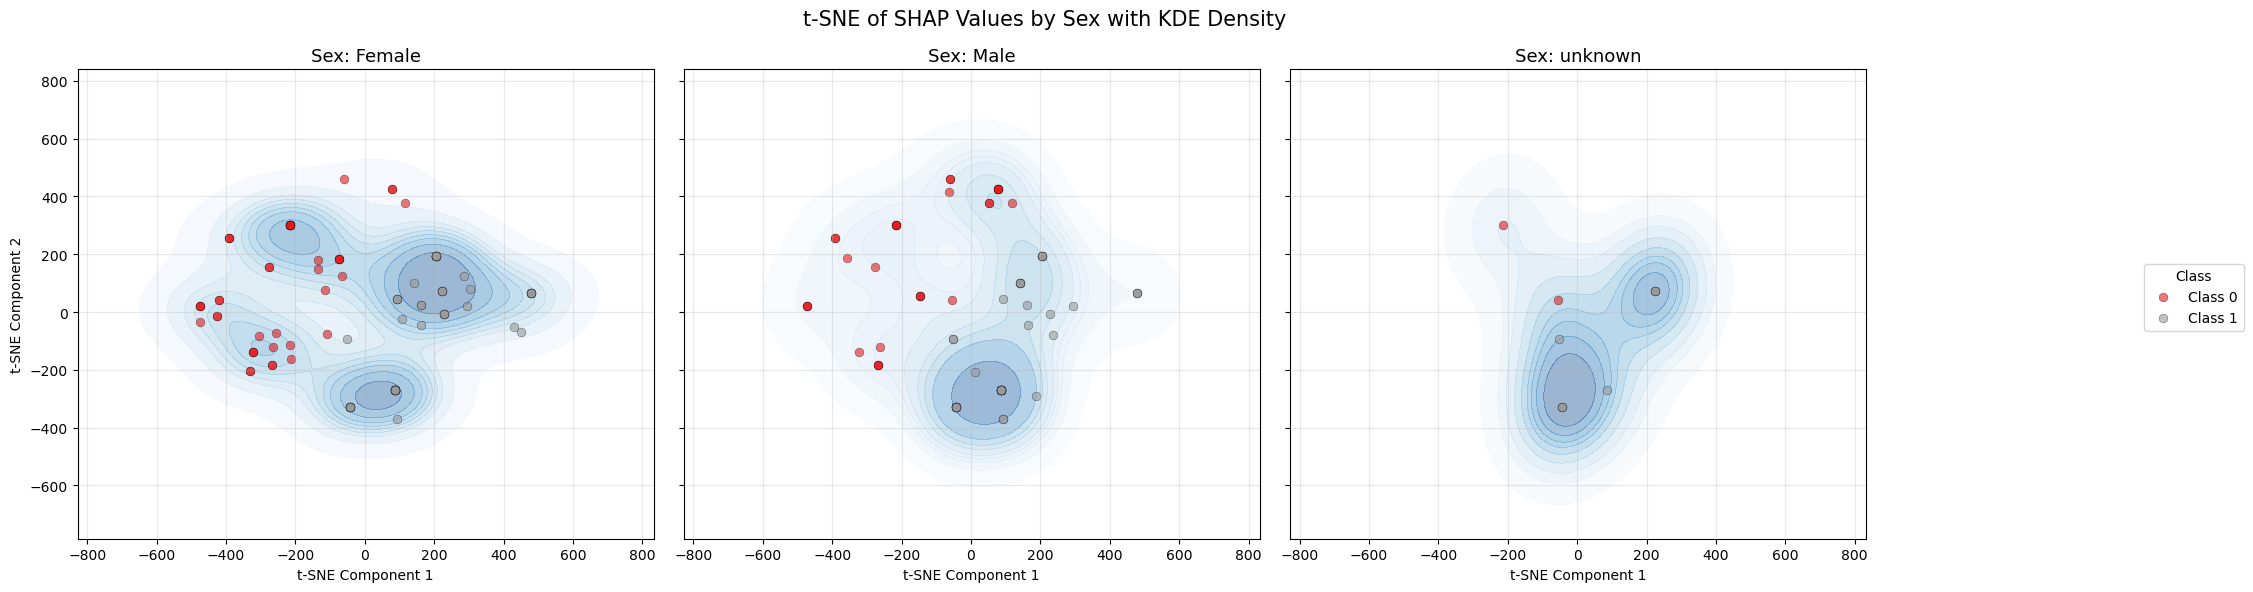

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Fill missing sex
tsne_df["sex"] = tsne_df["sex"].fillna("unknown")

unique_labels = np.unique(tsne_df["label"])
unique_sex = np.unique(tsne_df["sex"])
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))

# Create subplots per sex
fig, axes = plt.subplots(1, len(unique_sex), figsize=(7 * len(unique_sex), 6), sharex=True, sharey=True)

if len(unique_sex) == 1:
    axes = [axes]

for ax, s in zip(axes, unique_sex):
    subset = tsne_df[tsne_df["sex"] == s]
    
    # Draw KDE background
    sns.kdeplot(
        data=subset,
        x="TSNE1", y="TSNE2",
        fill=True, cmap="Blues", alpha=0.4, ax=ax, thresh=0.05
    )
    
    # Scatter by class on top
    for i, lbl in enumerate(unique_labels):
        mask = subset["label"] == lbl
        ax.scatter(
            subset.loc[mask, "TSNE1"],
            subset.loc[mask, "TSNE2"],
            color=colors[i],
            label=f"Class {lbl}",
            alpha=0.6,
            s=40,
            edgecolors="black",
            linewidth=0.3
        )
    
    ax.set_title(f"Sex: {s}", fontsize=13)
    ax.set_xlabel("t-SNE Component 1")
    ax.set_ylabel("t-SNE Component 2")
    ax.grid(True, alpha=0.3)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 0.5), loc="center left", title="Class")
plt.suptitle("t-SNE of SHAP Values by Sex with KDE Density", fontsize=15)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


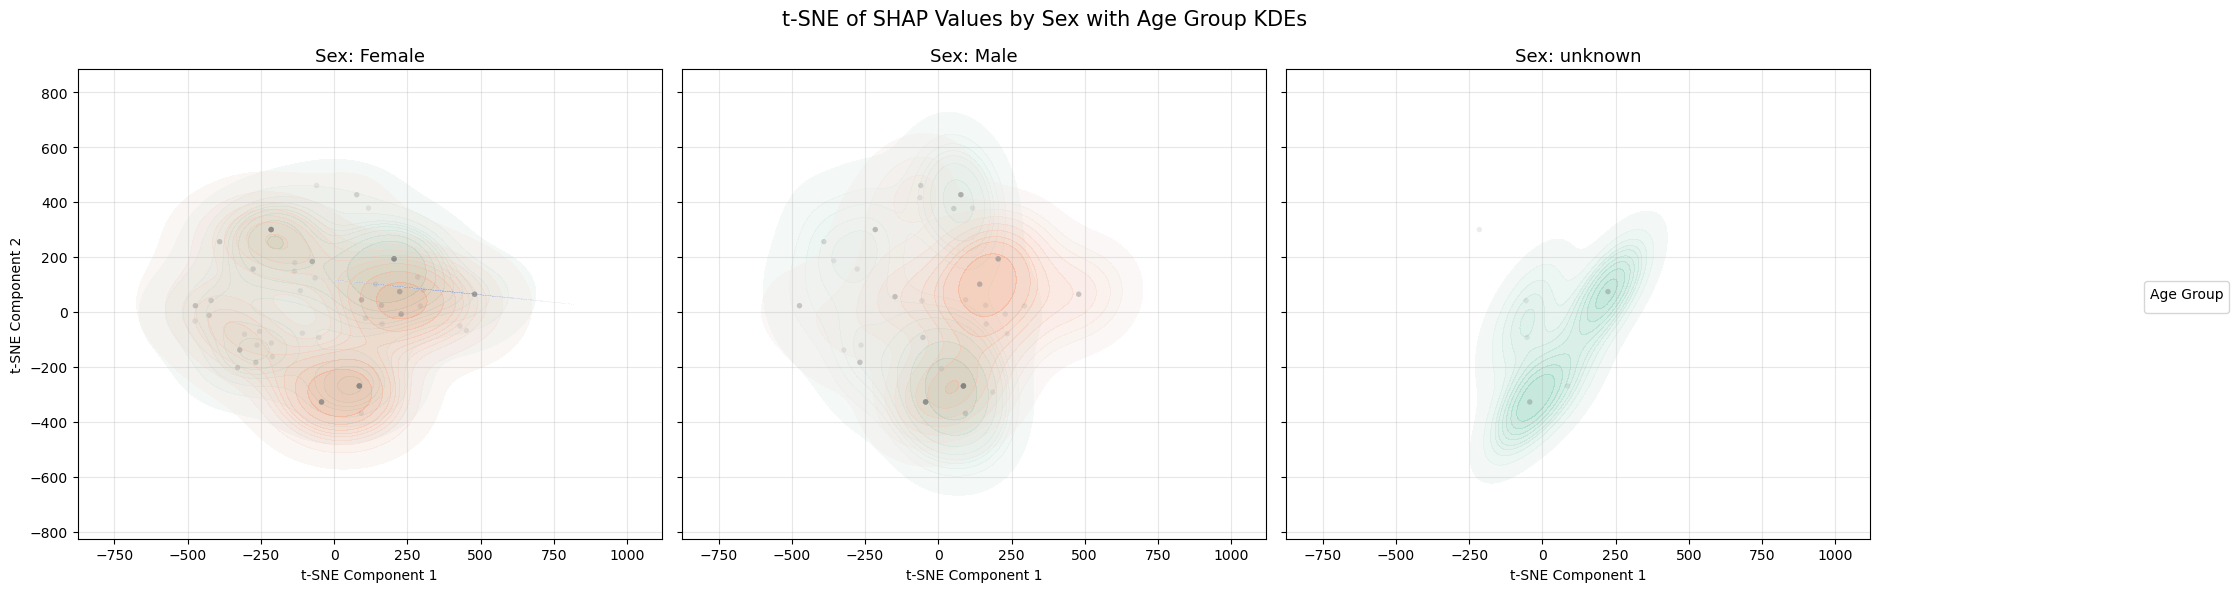

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ensure sex is filled
tsne_df["sex"] = tsne_df["sex"].fillna("unknown")

# Unique values
unique_sex = np.unique(tsne_df["sex"])
unique_groups = np.unique(tsne_df["group"])

# Set color palette for age groups
palette = sns.color_palette("Set2", len(unique_groups))

# Create subplots (one per sex)
fig, axes = plt.subplots(1, len(unique_sex), figsize=(7 * len(unique_sex), 6), sharex=True, sharey=True)

if len(unique_sex) == 1:
    axes = [axes]

for ax, s in zip(axes, unique_sex):
    subset = tsne_df[tsne_df["sex"] == s]
    
    # KDEs for each age group
    for grp, color in zip(unique_groups, palette):
        grp_data = subset[subset["group"] == grp]
        if len(grp_data) > 1:  # skip empty or single-sample groups
            sns.kdeplot(
                data=grp_data,
                x="TSNE1",
                y="TSNE2",
                fill=True,
                alpha=0.4,
                cmap=sns.light_palette(color, as_cmap=True),
                thresh=0.05,
                ax=ax,
                label=f"{grp}"
            )
    
    # Add scatter points faintly for context
    ax.scatter(
        subset["TSNE1"], subset["TSNE2"],
        color="gray", alpha=0.15, s=15, edgecolors="none"
    )
    
    ax.set_title(f"Sex: {s}", fontsize=13)
    ax.set_xlabel("t-SNE Component 1")
    ax.set_ylabel("t-SNE Component 2")
    ax.grid(True, alpha=0.3)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 0.5), loc="center left", title="Age Group")

plt.suptitle("t-SNE of SHAP Values by Sex with Age Group KDEs", fontsize=15)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


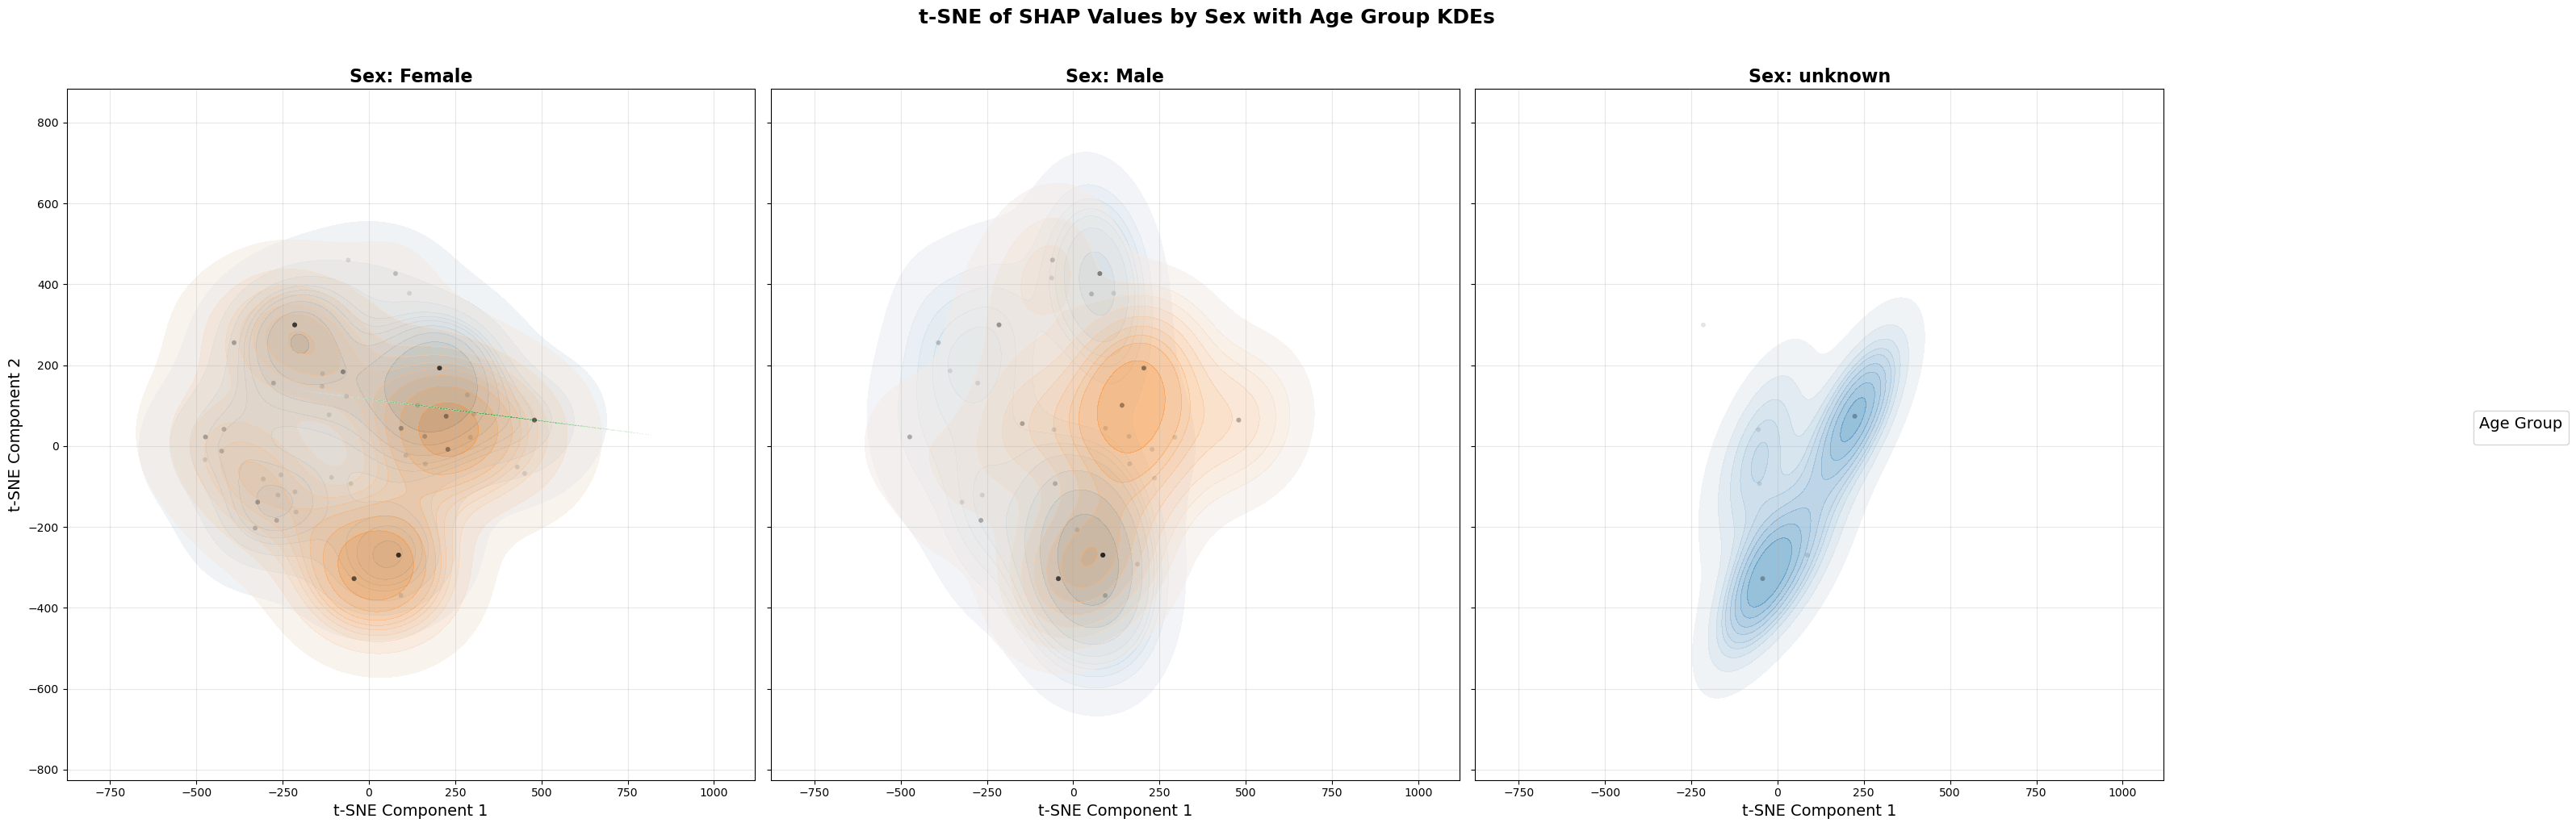

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ensure missing values are handled
tsne_df["sex"] = tsne_df["sex"].fillna("unknown")

# Unique values
unique_sex = np.unique(tsne_df["sex"])
unique_groups = np.unique(tsne_df["group"])

# 🎨 Use a high-contrast color palette for groups
# (tab10, Dark2, or Spectral are great for separation)
palette = sns.color_palette("tab10", len(unique_groups))

# 🖼️ Make a larger figure with consistent layout
fig, axes = plt.subplots(
    1, len(unique_sex),
    figsize=(10 * len(unique_sex), 10),  # wider and taller
    sharex=True, sharey=True
)

if len(unique_sex) == 1:
    axes = [axes]

for ax, s in zip(axes, unique_sex):
    subset = tsne_df[tsne_df["sex"] == s]
    
    # KDEs for each age group
    for grp, color in zip(unique_groups, palette):
        grp_data = subset[subset["group"] == grp]
        if len(grp_data) > 1:
            sns.kdeplot(
                data=grp_data,
                x="TSNE1", y="TSNE2",
                fill=True,
                alpha=0.5,
                cmap=sns.light_palette(color, as_cmap=True),
                thresh=0.05,
                ax=ax,
                label=f"{grp}"
            )
    
    # Faint scatter for all points
    ax.scatter(
        subset["TSNE1"], subset["TSNE2"],
        color="black", alpha=0.1, s=18, edgecolors="none"
    )
    
    ax.set_title(f"Sex: {s}", fontsize=16, weight="bold")
    ax.set_xlabel("t-SNE Component 1", fontsize=14)
    ax.set_ylabel("t-SNE Component 2", fontsize=14)
    ax.grid(True, alpha=0.3)

# 🌈 Shared legend with clear layout
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    title="Age Group",
    fontsize=13,
    title_fontsize=14
)

plt.suptitle("t-SNE of SHAP Values by Sex with Age Group KDEs", fontsize=18, weight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


In [149]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Drop missing sex values
tsne_df_clean = tsne_df.dropna(subset=["sex"]).copy()

# Define unique groups and sexes
unique_groups = np.unique(tsne_df_clean["group"])
unique_sex = np.unique(tsne_df_clean["sex"])

# Define distinct colors for groups (e.g. Set2 or tab10 for better contrast)
palette = sns.color_palette("tab10", len(unique_groups))

# Create separate plots by sex
for sex in unique_sex:
    subset = tsne_df_clean[tsne_df_clean["sex"] == sex]
    
    plt.figure(figsize=(10, 8))
    sns.kdeplot(
        data=subset,
        x="x", y="y",
        hue="group",
        fill=True,
        alpha=0.5,
        palette=palette,
        common_norm=False
    )
    
    plt.title(f"t-SNE Distribution by Age Group ({sex})", fontsize=16)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(title="Group")
    plt.grid(alpha=0.3)
    plt.show()


ValueError: Could not interpret value `x` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x800 with 0 Axes>

In [91]:
# shap_df.to_csv('rural_shap.csv')

In [ ]:
shap_df.

In [87]:
shap_values_class1.shape

(199, 1262)

In [39]:
import shap
import numpy as np

In [58]:
explainer = shap.Explainer(model2)

In [59]:
shap_values = explainer.shap_values(data_sp2)

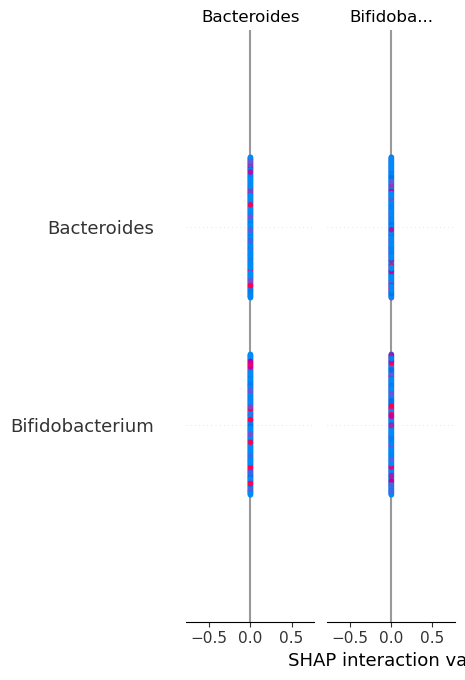

In [61]:
shap.summary_plot(shap_values, data_sp2)

In [54]:
print(shap_values[:, :, 0].shape, data_sp2.shape)

(199, 1262) (199, 1262)


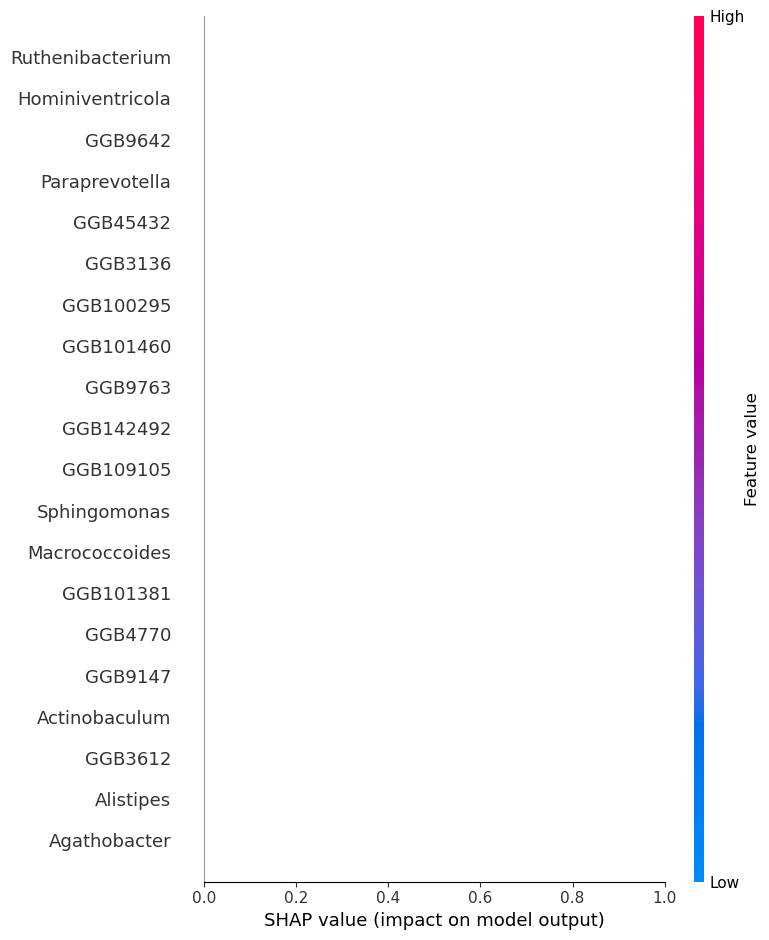

In [56]:
shap.summary_plot(
    shap_values[:, :, 0], 
    data_sp2, 
    feature_names=data_sp2.columns,
    plot_type="bee"
)

In [64]:
import xgboost as xgb
import shap
import pandas as pd
import json

# Fit XGBoost classifier with default parameters
model = xgb.XGBClassifier()
model.fit(data_sp2, label)

# Get predictions
predictions = model.predict(data_sp2)

# Fix the base_score issue
booster = model.get_booster()
config = json.loads(booster.save_config())

# Extract the base_score value from the array string
base_score_str = config['learner']['learner_model_param']['base_score']
if base_score_str.startswith('[') and base_score_str.endswith(']'):
    # Remove brackets and convert to float
    base_score_value = float(base_score_str.strip('[]'))
    config['learner']['learner_model_param']['base_score'] = str(base_score_value)
    booster.load_config(json.dumps(config))

# Now create the SHAP explainer
explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(data_sp2)

# Create DataFrame with SHAP values
shap_df = pd.DataFrame(shap_values, columns=data_sp2.columns)

print("Predictions shape:", predictions.shape)
print("SHAP values shape:", shap_values.shape)
print("\nFirst few SHAP values:")
print(shap_df.head())

ValueError: could not convert string to float: '[5.879397E-1]'

In [67]:
from sklearn.tree import DecisionTreeClassifier
import shap
import pandas as pd

# Fit Decision Tree classifier with default parameters
model = DecisionTreeClassifier()
model.fit(data_sp2, label)

# Get predictions
predictions = model.predict(data_sp2)

# Calculate SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(data_sp2)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Number of samples: {shap_values.shape[0]}")
print(f"Number of features: {shap_values.shape[1]}")
print(f"Number of classes: {shap_values.shape[2]}")

# For binary classification with shape (n_samples, n_features, 2)
# Extract SHAP values for class 1 (positive class)
shap_values_class1 = shap_values[:, :, 1]

# Create DataFrame with SHAP values for class 1
shap_df = pd.DataFrame(shap_values_class1, columns=data_sp2.columns)

print("\nSHAP values for class 1 (positive class):")
print(shap_df.head())

# If you want SHAP values for class 0 as well:
shap_values_class0 = shap_values[:, :, 0]
shap_df_class0 = pd.DataFrame(shap_values_class0, columns=data_sp2.columns)

print("\nSHAP values for class 0 (negative class):")
print(shap_df_class0.head())

SHAP values shape: (199, 1262, 2)
Number of samples: 199
Number of features: 1262
Number of classes: 2

SHAP values for class 1 (positive class):
   Bacteroides  Bifidobacterium  Phocaeicola  Fusicatenibacter  Roseburia  \
0          0.0              0.0          0.0               0.0        0.0   
1          0.0              0.0          0.0               0.0        0.0   
2          0.0              0.0          0.0               0.0        0.0   
3          0.0              0.0          0.0               0.0        0.0   
4          0.0              0.0          0.0               0.0        0.0   

   Hominilimicola  Blautia  Faecalibacterium  GGB4605  Ruminococcus  ...  \
0             0.0      0.0               0.0      0.0           0.0  ...   
1             0.0      0.0               0.0      0.0           0.0  ...   
2             0.0      0.0               0.0      0.0           0.0  ...   
3             0.0      0.0               0.0      0.0           0.0  ...   
4          

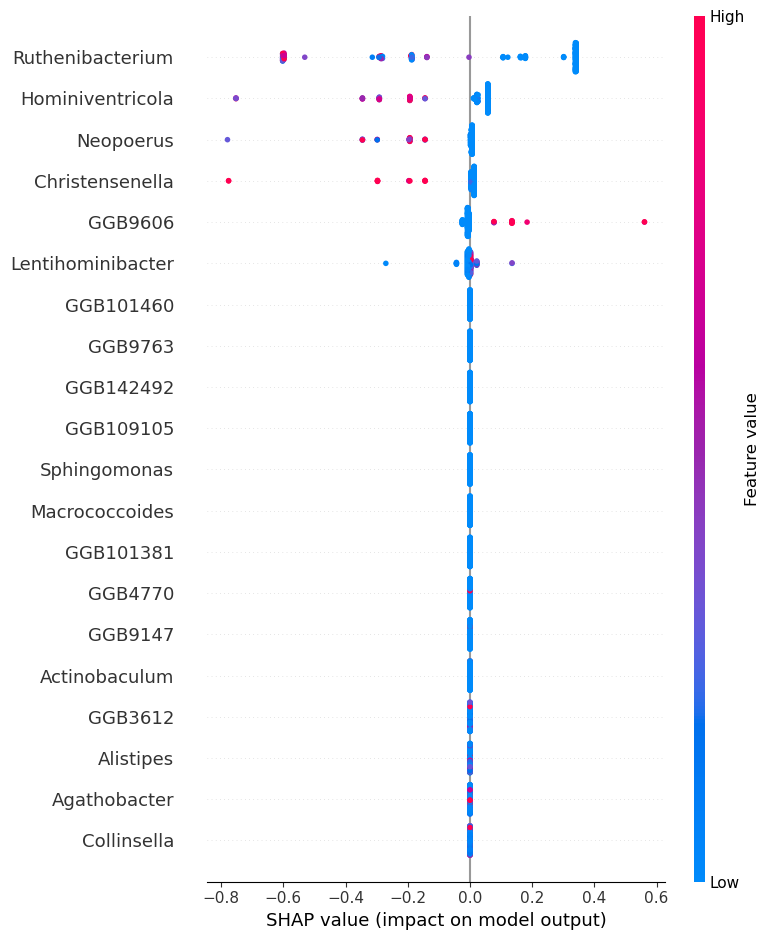

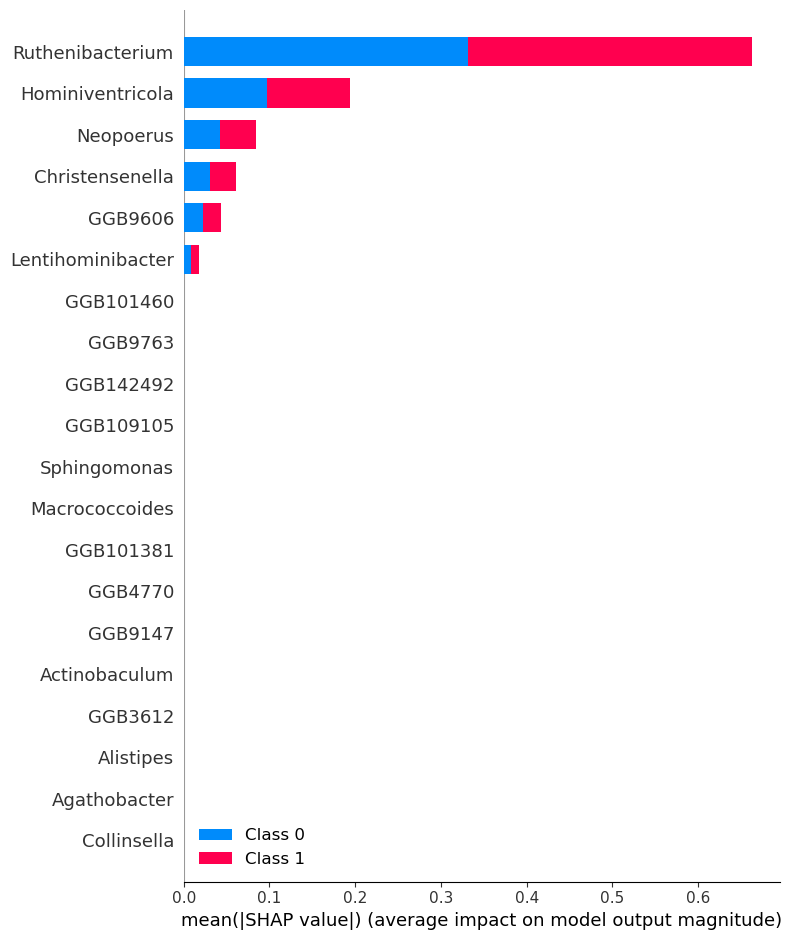

In [68]:
# Summary plot for class 1
shap.summary_plot(shap_values[:, :, 1], data_sp2)

# Or use the list format for visualization
shap.summary_plot([shap_values[:, :, 0], shap_values[:, :, 1]], data_sp2)

Top 20 Most Important Features:
               feature  importance
30    Ruthenibacterium    0.734281
439   Hominiventricola    0.164743
656           GGB45432    0.040081
104            GGB9642    0.026504
429     Paraprevotella    0.020563
858            GGB3136    0.013828
2          Phocaeicola    0.000000
3     Fusicatenibacter    0.000000
4            Roseburia    0.000000
5       Hominilimicola    0.000000
6              Blautia    0.000000
7     Faecalibacterium    0.000000
8              GGB4605    0.000000
9         Ruminococcus    0.000000
10        Anaerostipes    0.000000
11         Collinsella    0.000000
12        Agathobacter    0.000000
13           Alistipes    0.000000
14             GGB3612    0.000000
1247     Actinobaculum    0.000000


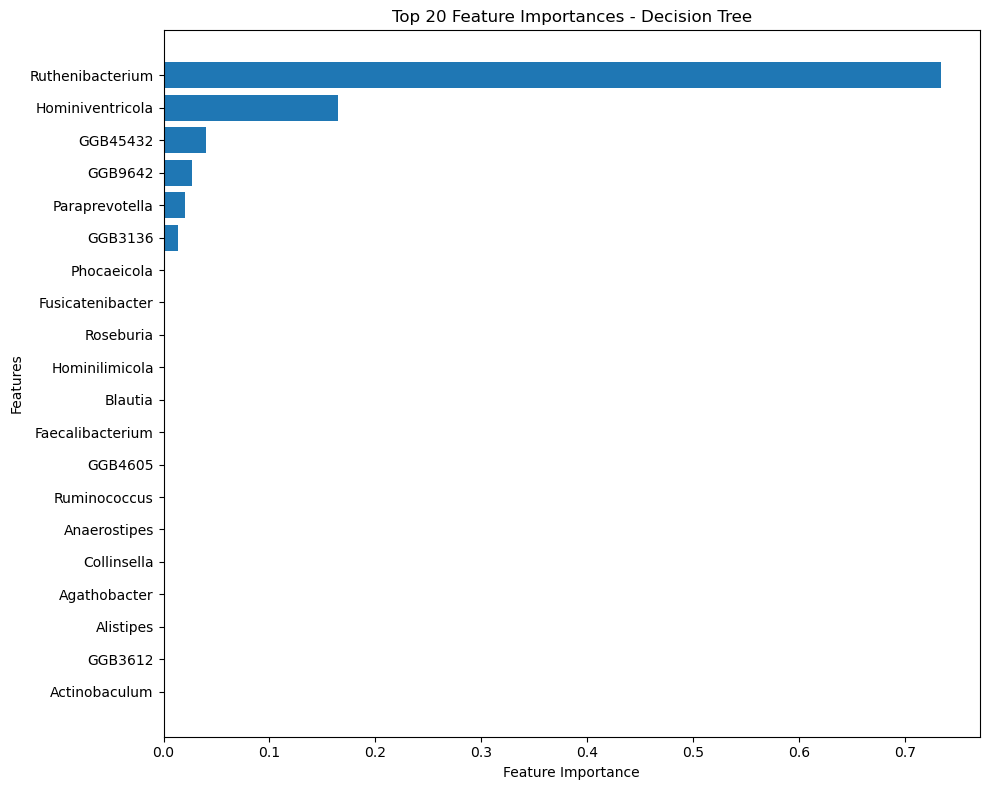

In [70]:

import matplotlib.pyplot as plt


# Get feature importances from the trained model
feature_importances = model2.feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': data_sp2.columns,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print(importance_df.head(20))

# Plot 1: Bar plot of top N features
plt.figure(figsize=(10, 8))
top_n = 20  # Change this to show more or fewer features
top_features = importance_df.head(top_n)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title(f'Top {top_n} Feature Importances - Decision Tree')
plt.gca().invert_yaxis()  # Highest importance at top
plt.tight_layout()
plt.show()


In [57]:
model2.feature_importance()

AttributeError: 'DecisionTreeClassifier' object has no attribute 'feature_importance'